In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Big Data Analysis") \
    .getOrCreate()

In [4]:
import urllib.request

# Download dataset
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"
urllib.request.urlretrieve(url, "chipotle.tsv")

# Read using Spark
df = spark.read.csv("chipotle.tsv", header=True, sep="\t", inferSchema=True)

df.show(5)

+--------+--------+--------------------+--------------------+----------+
|order_id|quantity|           item_name|  choice_description|item_price|
+--------+--------+--------------------+--------------------+----------+
|       1|       1|Chips and Fresh T...|                NULL|    $2.39 |
|       1|       1|                Izze|        [Clementine]|    $3.39 |
|       1|       1|    Nantucket Nectar|             [Apple]|    $3.39 |
|       1|       1|Chips and Tomatil...|                NULL|    $2.39 |
|       2|       2|        Chicken Bowl|[Tomatillo-Red Ch...|   $16.98 |
+--------+--------+--------------------+--------------------+----------+
only showing top 5 rows


In [5]:
df.printSchema()

df.describe().show()

root
 |-- order_id: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- item_name: string (nullable = true)
 |-- choice_description: string (nullable = true)
 |-- item_price: string (nullable = true)

+-------+-----------------+------------------+-----------------+--------------------+----------+
|summary|         order_id|          quantity|        item_name|  choice_description|item_price|
+-------+-----------------+------------------+-----------------+--------------------+----------+
|  count|             4622|              4622|             4622|                4622|      4622|
|   mean|927.2548680225011|1.0757247944612722|             NULL|                NULL|      NULL|
| stddev|528.8907955866096|0.4101863342575333|             NULL|                NULL|      NULL|
|    min|                1|                 1|6 Pack Soft Drink|                NULL|    $1.09 |
|    max|             1834|                15|Veggie Soft Tacos|[[Tomatillo-Red C...|    $9.39 |
+--

In [6]:
from pyspark.sql.functions import col, regexp_replace

df = df.withColumn(
    "item_price",
    regexp_replace(col("item_price"), "\$", "").cast("float")
)

df.show(5)

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_878/1691499549.py:5: SyntaxWarning: invalid escape sequence '\$'
  regexp_replace(col("item_price"), "\$", "").cast("float")


+--------+--------+--------------------+--------------------+----------+
|order_id|quantity|           item_name|  choice_description|item_price|
+--------+--------+--------------------+--------------------+----------+
|       1|       1|Chips and Fresh T...|                NULL|      2.39|
|       1|       1|                Izze|        [Clementine]|      3.39|
|       1|       1|    Nantucket Nectar|             [Apple]|      3.39|
|       1|       1|Chips and Tomatil...|                NULL|      2.39|
|       2|       2|        Chicken Bowl|[Tomatillo-Red Ch...|     16.98|
+--------+--------+--------------------+--------------------+----------+
only showing top 5 rows


In [7]:
from pyspark.sql.functions import sum

total_revenue = df.select(sum("item_price")).collect()[0][0]
print("Total Revenue:", total_revenue)

Total Revenue: 34500.159754514694


In [8]:
from pyspark.sql.functions import desc

most_ordered = df.groupBy("item_name") \
    .sum("quantity") \
    .orderBy(desc("sum(quantity)"))

most_ordered.show(5)

+-------------------+-------------+
|          item_name|sum(quantity)|
+-------------------+-------------+
|       Chicken Bowl|          761|
|    Chicken Burrito|          591|
|Chips and Guacamole|          506|
|      Steak Burrito|          386|
|  Canned Soft Drink|          351|
+-------------------+-------------+
only showing top 5 rows


In [9]:
orders = df.groupBy("order_id").count()
orders.show(5)

+--------+-----+
|order_id|count|
+--------+-----+
|     148|    4|
|     463|    2|
|     471|    5|
|     496|    5|
|     833|    2|
+--------+-----+
only showing top 5 rows


In [10]:
df.orderBy(col("item_price").desc()).show(5)

+--------+--------+--------------------+--------------------+----------+
|order_id|quantity|           item_name|  choice_description|item_price|
+--------+--------+--------------------+--------------------+----------+
|    1443|      15|Chips and Fresh T...|                NULL|     44.25|
|    1398|       3|       Carnitas Bowl|[Roasted Chili Co...|     35.25|
|     511|       4|     Chicken Burrito|[Fresh Tomato Sal...|      35.0|
|    1443|       4|     Chicken Burrito|[Fresh Tomato Sal...|      35.0|
|    1443|       3|      Veggie Burrito|[Fresh Tomato Sal...|     33.75|
+--------+--------+--------------------+--------------------+----------+
only showing top 5 rows


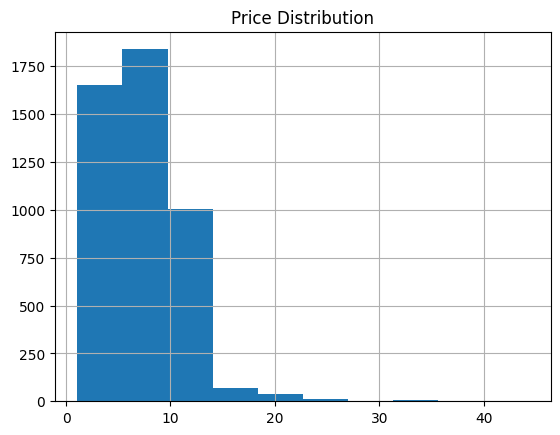

In [11]:
pandas_df = df.toPandas()

import matplotlib.pyplot as plt

pandas_df["item_price"].hist()
plt.title("Price Distribution")
plt.show()